# Step 10: History-Length Ablation (ANN–LSTM)

## Question

In notebook 09, **ANN–LSTM with 60 days** of history beat persistence.
But is 60 days actually useful — or would shorter/longer work better?

This notebook trains the **same ANN–LSTM** five times, changing only history length:

| Experiment | Historical input |
|------------|------------------|
| A | **7** days |
| B | **14** days |
| C | **30** days |
| D | **60** days |
| E | **90** days |

Everything else stays fixed: architecture, horizons (+1/+3/+7), data split, seed.

> **Standalone** — does not modify notebook 09 or any other existing files.

## What “good” looks like

- If MAE **drops** from 7 → 30 → 60 → then flattens: history helps up to a point  
- If **60 ≈ 90**: 60 days is enough (90 is unnecessarily long)  
- If **7 ≈ 60**: short memory is enough; long history wasn’t the real win  
- Always compare against **persistence** on the same issues

## Import libraries

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")

from prepare_data import load_all_locations, time_holdout_split, apply_scalers, fit_scalers

print("TensorFlow", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.20.0
GPU: []


## Fixed settings (only LOOKBACK changes)

In [2]:
LOOKBACKS = [7, 14, 30, 60, 90]   # experiments A–E
HORIZONS = [1, 3, 7]
BATCH_SIZE = 64
EPOCHS = 50
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

OUT_DIR = Path("lstm_lookback_ablation")
OUT_DIR.mkdir(exist_ok=True)

print("LOOKBACKS:", LOOKBACKS)
print("HORIZONS :", HORIZONS)
print("Outputs  :", OUT_DIR.resolve())

LOOKBACKS: [7, 14, 30, 60, 90]
HORIZONS : [1, 3, 7]
Outputs  : D:\corals\model\lstm_lookback_ablation


## Load data (same split as the rest of the project)

In [3]:
df = load_all_locations()
scalers = fit_scalers(df)
df = apply_scalers(df, scalers)
train_df, val_df, test_df = time_holdout_split(df, val_frac=0.1, test_frac=0.1)

print(f"train {train_df['time'].min().date()} → {train_df['time'].max().date()}  n={len(train_df)}")
print(f"val   {val_df['time'].min().date()} → {val_df['time'].max().date()}  n={len(val_df)}")
print(f"test  {test_df['time'].min().date()} → {test_df['time'].max().date()}  n={len(test_df)}")

train 2015-03-01 → 2023-12-18  n=16075
val   2023-12-19 → 2025-01-23  n=2010
test  2025-01-24 → 2026-03-01  n=2010


## Sequence builder + ANN–LSTM (same as notebook 09)

In [4]:
def build_sequence_dataset(split_df, lookback, horizons=HORIZONS):
    """X: (N, lookback, 2) SST/DHW norm | y: (N, 6) multi-horizon targets."""
    Xs, ys, metas = [], [], []
    h_max = max(horizons)

    for loc, g in split_df.groupby("location"):
        g = g.sort_values("time").reset_index(drop=True)
        sst = g["temp_norm"].values.astype(np.float32)
        dhw = g["dhw_norm"].values.astype(np.float32)
        sst_phys = g["analysed_sst"].values.astype(np.float32)

        for i in range(lookback - 1, len(g) - h_max):
            window = np.stack(
                [sst[i - lookback + 1 : i + 1], dhw[i - lookback + 1 : i + 1]],
                axis=-1,
            )
            target = []
            row_meta = {
                "location": loc,
                "time_issue": g.loc[i, "time"],
                "sst_issue": float(sst_phys[i]),
            }
            ok = True
            for h in horizons:
                j = i + h
                if (g.loc[j, "time"] - g.loc[i, "time"]).days != h:
                    ok = False
                    break
                target.extend([sst[j], dhw[j]])
                row_meta[f"sst_t{h}"] = float(sst_phys[j])
            if not ok:
                continue
            Xs.append(window)
            ys.append(target)
            metas.append(row_meta)

    return (
        np.asarray(Xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
        pd.DataFrame(metas),
    )


def build_ann_lstm(lookback, n_features=2, n_outputs=6):
    """Identical architecture for every lookback — only input length changes."""
    inp = layers.Input(shape=(lookback, n_features), name="seq_input")
    x = layers.TimeDistributed(layers.Dense(32, activation="relu"))(inp)
    x = layers.LSTM(64, return_sequences=False)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(n_outputs, activation="sigmoid")(x)
    model = keras.Model(inp, out, name=f"ANN_LSTM_L{lookback}")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


def inverse_temp(vals):
    vals = np.asarray(vals, dtype=float).reshape(-1, 1)
    fn = getattr(scalers["scaler_temp"], "feature_names_in_", None)
    if fn is not None and len(fn):
        return scalers["scaler_temp"].inverse_transform(
            pd.DataFrame(vals, columns=fn)
        ).ravel()
    return scalers["scaler_temp"].inverse_transform(vals).ravel()


def decode_sst(y_norm):
    """Return dict horizon -> physical SST array from (N, 6) norm predictions."""
    y_norm = np.asarray(y_norm)
    return {h: inverse_temp(y_norm[:, 2 * k]) for k, h in enumerate(HORIZONS)}


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_pred) - np.asarray(y_true))))


print("Helpers ready")

Helpers ready


## Run ablation loop (A–E)

For each lookback:
1. Build sequences  
2. Train ANN–LSTM  
3. Score SST MAE vs persistence on that lookback’s test set  

Longer lookbacks have slightly fewer samples (need more past days) — we report `n` so you can see that.

In [5]:
all_rows = []
histories = {}

for L in LOOKBACKS:
    print("\n" + "=" * 70)
    print(f"LOOKBACK = {L} days")
    print("=" * 70)

    X_tr, y_tr, meta_tr = build_sequence_dataset(train_df, L)
    X_va, y_va, meta_va = build_sequence_dataset(val_df, L)
    X_te, y_te, meta_te = build_sequence_dataset(test_df, L)
    print(f"  train={len(X_tr)}  val={len(X_va)}  test={len(X_te)}")

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = build_ann_lstm(L)
    ckpt = str(OUT_DIR / f"ann_lstm_L{L}_best.h5")
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=0),
            ModelCheckpoint(ckpt, monitor="val_loss", save_best_only=True, verbose=0),
        ],
        verbose=0,
    )
    histories[L] = hist.history
    pd.DataFrame(hist.history).to_csv(OUT_DIR / f"history_L{L}.csv", index=False)
    model.save(str(OUT_DIR / f"ann_lstm_L{L}_final.h5"))

    pred = decode_sst(model.predict(X_te, verbose=0))
    best_val = float(min(hist.history["val_loss"]))

    for h in HORIZONS:
        y_true = meta_te[f"sst_t{h}"].values
        persist = meta_te["sst_issue"].values
        mae_model = mae(y_true, pred[h])
        mae_persist = mae(y_true, persist)
        all_rows.append({
            "lookback": L,
            "horizon_days": h,
            "ann_lstm_mae": mae_model,
            "persistence_mae": mae_persist,
            "skill_vs_persistence": 1.0 - mae_model / max(mae_persist, 1e-6),
            "n_test": len(y_true),
            "n_train": len(X_tr),
            "best_val_loss": best_val,
            "epochs_run": len(hist.history["loss"]),
        })
        print(
            f"  {h}d  ANN–LSTM MAE={mae_model:.4f}  "
            f"persist={mae_persist:.4f}  "
            f"skill={1.0 - mae_model / max(mae_persist, 1e-6):+.3f}"
        )

results = pd.DataFrame(all_rows)
results.to_csv(OUT_DIR / "lookback_ablation_results.csv", index=False)
print("\nSaved", OUT_DIR / "lookback_ablation_results.csv")
results


LOOKBACK = 7 days
  train=16010  val=1945  test=1945



  1d  ANN–LSTM MAE=0.1581  persist=0.1530  skill=-0.033
  3d  ANN–LSTM MAE=0.2368  persist=0.2375  skill=+0.003
  7d  ANN–LSTM MAE=0.3174  persist=0.3244  skill=+0.022

LOOKBACK = 14 days
  train=15975  val=1910  test=1910


  1d  ANN–LSTM MAE=0.1551  persist=0.1535  skill=-0.011
  3d  ANN–LSTM MAE=0.2360  persist=0.2380  skill=+0.008
  7d  ANN–LSTM MAE=0.3196  persist=0.3255  skill=+0.018

LOOKBACK = 30 days
  train=15895  val=1830  test=1830


  1d  ANN–LSTM MAE=0.1605  persist=0.1563  skill=-0.027
  3d  ANN–LSTM MAE=0.2385  persist=0.2400  skill=+0.006
  7d  ANN–LSTM MAE=0.3165  persist=0.3233  skill=+0.021

LOOKBACK = 60 days
  train=15745  val=1680  test=1680


  1d  ANN–LSTM MAE=0.1552  persist=0.1563  skill=+0.007
  3d  ANN–LSTM MAE=0.2292  persist=0.2397  skill=+0.044
  7d  ANN–LSTM MAE=0.2960  persist=0.3198  skill=+0.074

LOOKBACK = 90 days
  train=15595  val=1530  test=1530


  1d  ANN–LSTM MAE=0.1598  persist=0.1592  skill=-0.004
  3d  ANN–LSTM MAE=0.2321  persist=0.2441  skill=+0.049
  7d  ANN–LSTM MAE=0.2982  persist=0.3302  skill=+0.097

Saved lstm_lookback_ablation\lookback_ablation_results.csv


,lookback,horizon_days,ann_lstm_mae,persistence_mae,skill_vs_persistence,n_test,n_train,best_val_loss,epochs_run
0,7,1,0.158083,0.153049,-0.032891,1945,16010,0.001405,40
1,7,3,0.236838,0.237455,0.002598,1945,16010,0.001405,40
2,7,7,0.317377,0.324391,0.021621,1945,16010,0.001405,40
3,14,1,0.155148,0.153461,-0.010992,1910,15975,0.001385,38
4,14,3,0.236045,0.238010,0.008259,1910,15975,0.001385,38
5,14,7,0.319575,0.325476,0.018133,1910,15975,0.001385,38
6,30,1,0.160522,0.156344,-0.026723,1830,15895,0.001325,23
7,30,3,0.238509,0.239995,0.006188,1830,15895,0.001325,23
8,30,7,0.316545,0.323268,0.020797,1830,15895,0.001325,23
9,60,1,0.155155,0.156310,0.007385,1680,15745,0.001428,45


## Results table (SST MAE °C)

In [6]:
pivot = results.pivot(index="lookback", columns="horizon_days", values="ann_lstm_mae")
pivot.columns = [f"MAE_{h}d" for h in pivot.columns]

persist_pivot = results.pivot(index="lookback", columns="horizon_days", values="persistence_mae")
persist_pivot.columns = [f"persist_{h}d" for h in persist_pivot.columns]

n_tbl = results.groupby("lookback").agg(n_train=("n_train", "first"), n_test=("n_test", "first"))
summary = pivot.join(n_tbl)
summary.to_csv(OUT_DIR / "lookback_mae_pivot.csv")

print("ANN–LSTM SST MAE by lookback (lower is better)")
print(summary.round(4).to_string())
print("\nPersistence MAE (same test issues per lookback)")
print(persist_pivot.round(4).to_string())
summary

ANN–LSTM SST MAE by lookback (lower is better)
          MAE_1d  MAE_3d  MAE_7d  n_train  n_test
lookback                                         
7         0.1581  0.2368  0.3174    16010    1945
14        0.1551  0.2360  0.3196    15975    1910
30        0.1605  0.2385  0.3165    15895    1830
60        0.1552  0.2292  0.2960    15745    1680
90        0.1598  0.2321  0.2982    15595    1530

Persistence MAE (same test issues per lookback)
          persist_1d  persist_3d  persist_7d
lookback                                    
7             0.1530      0.2375      0.3244
14            0.1535      0.2380      0.3255
30            0.1563      0.2400      0.3233
60            0.1563      0.2397      0.3198
90            0.1592      0.2441      0.3302


,MAE_1d,MAE_3d,MAE_7d,n_train,n_test
lookback,,,,,
7,0.158083,0.236838,0.317377,16010,1945
14,0.155148,0.236045,0.319575,15975,1910
30,0.160522,0.238509,0.316545,15895,1830
60,0.155155,0.229216,0.296006,15745,1680
90,0.159817,0.232142,0.298215,15595,1530


## Plot: does longer history help?

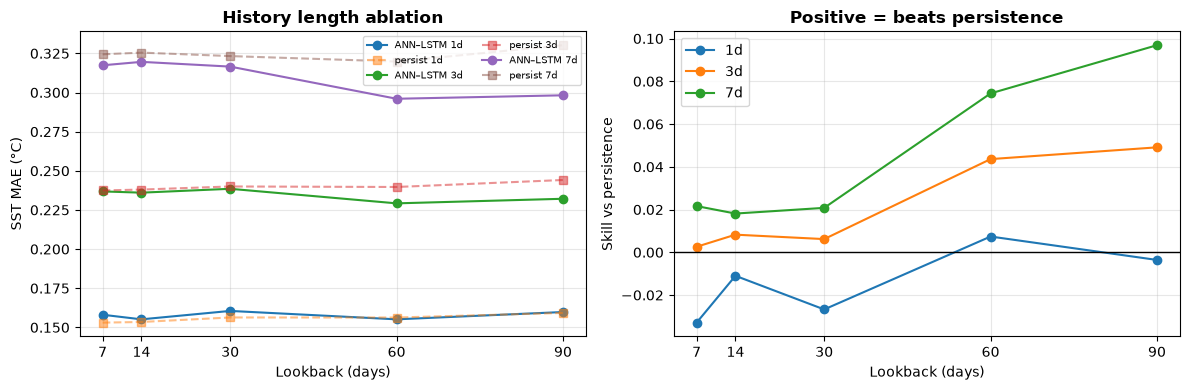

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: MAE vs lookback for each horizon
ax = axes[0]
for h in HORIZONS:
    sub = results[results.horizon_days == h].sort_values("lookback")
    ax.plot(sub["lookback"], sub["ann_lstm_mae"], "o-", label=f"ANN–LSTM {h}d")
    ax.plot(sub["lookback"], sub["persistence_mae"], "s--", alpha=0.5, label=f"persist {h}d")
ax.set_xlabel("Lookback (days)")
ax.set_ylabel("SST MAE (°C)")
ax.set_title("History length ablation", fontweight="bold")
ax.set_xticks(LOOKBACKS)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Right: skill vs persistence (positive = beats persistence)
ax = axes[1]
for h in HORIZONS:
    sub = results[results.horizon_days == h].sort_values("lookback")
    ax.plot(sub["lookback"], sub["skill_vs_persistence"], "o-", label=f"{h}d")
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Lookback (days)")
ax.set_ylabel("Skill vs persistence")
ax.set_title("Positive = beats persistence", fontweight="bold")
ax.set_xticks(LOOKBACKS)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "lookback_ablation_curves.png", dpi=130)
plt.show()

## Training curves (optional sanity check)

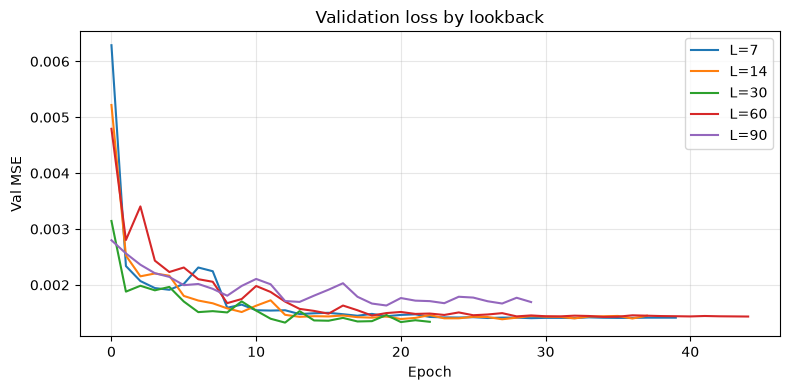

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for L in LOOKBACKS:
    ax.plot(histories[L]["val_loss"], label=f"L={L}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val MSE")
ax.set_title("Validation loss by lookback")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "lookback_val_loss.png", dpi=120)
plt.show()

## Automatic verdict

In [9]:
print("=" * 70)
print("LOOKBACK ABLATION VERDICT")
print("=" * 70)

for h in HORIZONS:
    sub = results[results.horizon_days == h].sort_values("ann_lstm_mae")
    best = sub.iloc[0]
    at60 = sub[sub.lookback == 60].iloc[0]
    print(f"\n{h}-day forecast:")
    print(f"  best lookback : {int(best['lookback']):2d} days   MAE={best['ann_lstm_mae']:.4f} °C")
    print(f"  60-day (nb09) : 60 days   MAE={at60['ann_lstm_mae']:.4f} °C")
    print(f"  skill @ best  : {best['skill_vs_persistence']:+.3f} vs persistence")

# Overall: average MAE across horizons
avg = (
    results.groupby("lookback")["ann_lstm_mae"]
    .mean()
    .sort_values()
    .rename("mean_mae_1_3_7")
)
print("\nMean MAE across 1/3/7-day (overall ranking):")
print(avg.round(4).to_string())
winner = int(avg.index[0])
print(f"\n→ Recommended lookback for ANN–LSTM: {winner} days")

if winner == 60:
    print("  60 days from notebook 09 looks well-chosen.")
elif winner < 60:
    print(f"  Shorter than 60 is enough — 60 may be unnecessarily long.")
else:
    print(f"  Longer than 60 helps — consider upgrading from 60 → {winner}.")

print("\nArtefacts in", OUT_DIR.resolve())
for p in sorted(OUT_DIR.glob("*")):
    print(" -", p.name)

LOOKBACK ABLATION VERDICT

1-day forecast:
  best lookback : 14 days   MAE=0.1551 °C
  60-day (nb09) : 60 days   MAE=0.1552 °C
  skill @ best  : -0.011 vs persistence

3-day forecast:
  best lookback : 60 days   MAE=0.2292 °C
  60-day (nb09) : 60 days   MAE=0.2292 °C
  skill @ best  : +0.044 vs persistence

7-day forecast:
  best lookback : 60 days   MAE=0.2960 °C
  60-day (nb09) : 60 days   MAE=0.2960 °C
  skill @ best  : +0.074 vs persistence

Mean MAE across 1/3/7-day (overall ranking):
lookback
60    0.2268
90    0.2301
14    0.2369
7     0.2374
30    0.2385

→ Recommended lookback for ANN–LSTM: 60 days
  60 days from notebook 09 looks well-chosen.

Artefacts in D:\corals\model\lstm_lookback_ablation
 - ann_lstm_L14_best.h5
 - ann_lstm_L14_final.h5
 - ann_lstm_L30_best.h5
 - ann_lstm_L30_final.h5
 - ann_lstm_L60_best.h5
 - ann_lstm_L60_final.h5
 - ann_lstm_L7_best.h5
 - ann_lstm_L7_final.h5
 - ann_lstm_L90_best.h5
 - ann_lstm_L90_final.h5
 - history_L14.csv
 - history_L30.csv
 - hi

## Summary

| Experiment | Lookback |
|------------|----------|
| A | 7 |
| B | 14 |
| C | 30 |
| D | 60 |
| E | 90 |

Same ANN–LSTM, same horizons, same split — only history length changes.

**Outputs** → `lstm_lookback_ablation/`
- `lookback_ablation_results.csv`
- `lookback_mae_pivot.csv`
- `ann_lstm_L{7,14,30,60,90}_best.h5`
- plots

If 30 or 60 wins clearly and 90 is flat, you can keep the shorter window for faster training and simpler deployment.